# Libraries

In [20]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load Data From GitHub

In [21]:
ALZ_URL = "https://raw.githubusercontent.com/naomi-rlm/Alzheimer-s_vs_Parkinson-s_Group10/main/Data/MONDO_0004975_Alzheimers.tsv"
PD_URL = "https://raw.githubusercontent.com/naomi-rlm/Alzheimer-s_vs_Parkinson-s_Group10/main/Data/MONDO_0005180_Parkinsons.tsv"

# Converts data to .csv format
def read_tsv(url_or_path: str) -> pd.DataFrame:
    df = pd.read_csv(url_or_path, sep="\t", dtype=str, low_memory=False)

    df.columns = (
        df.columns.str.strip()
                 .str.lower()
                 .str.replace(r"\s+", "_", regex=True)
                 .str.replace(r"[^\w_]+", "", regex=True)
    )
    return df

alz_raw = read_tsv(ALZ_URL)
pd_raw  = read_tsv(PD_URL)

display(alz_raw.head(3))
display(pd_raw.head(3))

,riskallele,pvalue,pvalueannotation,riskfrequency,orvalue,beta,ci,mappedgenes,traitname,efotraits,bgtraits,accessionid,locations,pubmedid,author
0,rs757278-T,3E-6,-,NR,-,1.29405 unit decrease,[0.76-1.83],CTTNBP2,Early-onset Alzheimer's disease,early-onset Alzheimers disease,-,GCST90558102,7:117737591,39023044,Ge YJ
1,rs55889290-A,4E-7,-,NR,-,0.563058 unit decrease,[0.35-0.78],CES5A,Early-onset Alzheimer's disease,early-onset Alzheimers disease,-,GCST90558102,16:55912846,39023044,Ge YJ
2,rs11903348-C,7E-7,-,NR,-,0.52424 unit increase,[0.32-0.73],"RPL38P2,LINC01851",Early-onset Alzheimer's disease,early-onset Alzheimers disease,-,GCST90558102,2:77855346,39023044,Ge YJ


,riskallele,pvalue,pvalueannotation,riskfrequency,orvalue,beta,ci,mappedgenes,traitname,efotraits,bgtraits,accessionid,locations,pubmedid,author
0,chr21:46916033-?,8E-240,-,NR,1.719,-,[1.673-1.768],-,Early-onset Parkinson's disease,Young adult-onset Parkinsonism,-,GCST004138,-,28256260,Siitonen A
1,chr3:64699445-?,6E-44,-,NR,1.78,-,[1.707-1.857],-,Early-onset Parkinson's disease,Young adult-onset Parkinsonism,-,GCST004138,-,28256260,Siitonen A
2,chr12:27737074-?,1E-33,-,NR,1.4,-,[1.359-1.442],-,Early-onset Parkinson's disease,Young adult-onset Parkinsonism,-,GCST004138,-,28256260,Siitonen A


# Column Detecting Helper Functions

In [22]:
def find_col(df: pd.DataFrame, candidates):
    cols = list(df.columns)

    # exact match
    for c in candidates:
        if not c.startswith("re:") and c in cols:
            return c

    # substring match
    for c in candidates:
        if c.startswith("re:"):
            continue
        for col in cols:
            if c in col:
                return col

    # regex match
    for c in candidates:
        if not c.startswith("re:"):
            continue
        pat = re.compile(c.replace("re:", ""), re.IGNORECASE)
        for col in cols:
            if pat.search(col):
                return col

    return None

def safe_to_numeric(s: pd.Series) -> pd.Series:
    return pd.to_numeric(s.astype(str).str.replace(",", ""), errors="coerce")

# Data Integration

In [23]:
# Build one unified table with labeled disease
COLMAP = {
    "effect_allele": "riskallele",
    "p_value": "pvalue",
    "eaf": "riskfrequency",
    "odds_ratio": "orvalue",
    "beta": "beta",
    "mapped_gene": "mappedgenes",
    "reported_trait": "traitname",
    "study_accession": "accessionid",
    "pubmed_id": "pubmedid",
    "locations": "locations",
    "author": "author",
}

def build_unified(df_raw: pd.DataFrame, label_value: str, colmap: dict) -> pd.DataFrame:
    out = pd.DataFrame(index=df_raw.index)
    out["disease_label"] = label_value

    for new_col, raw_col in colmap.items():
        out[new_col] = df_raw[raw_col] if raw_col in df_raw.columns else np.nan

    return out.reset_index(drop=True)

# Combine ALZ + PD
alz = build_unified(alz_raw, "Alzheimers", COLMAP)
pds = build_unified(pd_raw,  "Parkinsons", COLMAP)

df0 = pd.concat([alz, pds], ignore_index=True)

print("\nAfter build + concat:")
print(df0["disease_label"].value_counts(dropna=False))

# Parse locations
def parse_locations_chrpos(loc):
    if pd.isna(loc):
        return (np.nan, np.nan)
    s = str(loc).strip()
    m = re.match(r"^(\d{1,2}|X|Y):(\d+)$", s, re.IGNORECASE)
    if not m:
        return (np.nan, np.nan)
    chrom = m.group(1).upper()
    pos = int(m.group(2))
    return (chrom, pos)

chrpos = df0["locations"].apply(parse_locations_chrpos)
df0["chr"] = chrpos.apply(lambda x: x[0])
df0["pos"] = chrpos.apply(lambda x: x[1])

df0["variant_key"] = np.where(
    df0["chr"].notna() & df0["pos"].notna(),
    df0["chr"].astype("string") + ":" + df0["pos"].astype("Int64").astype("string"),
    np.nan
)

# Check work
print("\nMissingness check:")
print("disease_label NaN %:", df0["disease_label"].isna().mean())
print("chr NaN %:", df0["chr"].isna().mean())
print("pos NaN %:", df0["pos"].isna().mean())

display(df0[["locations","chr","pos","disease_label"]].head(10))


After build + concat:
disease_label
Alzheimers    6505
Parkinsons     777
Name: count, dtype: int64

Missingness check:
disease_label NaN %: 0.0
chr NaN %: 0.19307882449876407
pos NaN %: 0.19307882449876407


,locations,chr,pos,disease_label
0,7:117737591,7,117737591.0,Alzheimers
1,16:55912846,16,55912846.0,Alzheimers
2,2:77855346,2,77855346.0,Alzheimers
3,2:237464057,2,237464057.0,Alzheimers
4,12:63711968,12,63711968.0,Alzheimers
5,5:179487781,5,179487781.0,Alzheimers
6,17:6444777,17,6444777.0,Alzheimers
7,2:24027965,2,24027965.0,Alzheimers
8,2:75561161,2,75561161.0,Alzheimers
9,17:76111754,17,76111754.0,Alzheimers


# Data Cleaning, Validation, and Feature Engineering

In [24]:
df = df0.copy()

# Standardizing text fields
TEXT_COLS = ["effect_allele","mapped_gene","reported_trait","study_accession","pubmed_id","author","locations"]
for c in TEXT_COLS:
    if c in df.columns:
        df[c] = (
            df[c].astype(str).str.strip()
              .replace({"": np.nan, "nan": np.nan, "None": np.nan, "-": np.nan})
        )

# Convert numeric columns
for c in ["p_value","eaf","odds_ratio","beta","pos"]:
    if c in df.columns:
        df[c] = safe_to_numeric(df[c])

# Validate p-values (0 < p <= 1)
df["p_invalid"] = df["p_value"].isna() | (df["p_value"] <= 0) | (df["p_value"] > 1)
df.loc[df["p_invalid"], "p_value"] = np.nan

# Derived features
df["neglog10_p"] = np.where(df["p_value"].notna(), -np.log10(df["p_value"]), np.nan)

def gene_count(s):
    if pd.isna(s): return np.nan
    parts = re.split(r"[;,|/]+", str(s))
    parts = [p.strip() for p in parts if p.strip() and p.strip().lower() != "nan"]
    return len(parts) if parts else np.nan

df["gene_count"] = df["mapped_gene"].apply(gene_count)

df = df.drop(columns=["variant_id"], errors="ignore")

# Drop exact duplicates
before = len(df)
df = df.drop_duplicates()
print("\nDropped exact duplicates:", before - len(df))


Dropped exact duplicates: 5


# Preliminary Results: EDA

### Define analysis dataset

In [25]:
# Core columns for EDA
CORE = ["disease_label","chr","pos","variant_key","p_value","neglog10_p","odds_ratio","eaf","mapped_gene","gene_count","reported_trait","study_accession"]

# Create a model subset for numeric comparisons
df_num = df.dropna(subset=["neglog10_p"]).copy()

### Basic Summary and Missing Values

In [26]:
print("Shape:", df.shape)

print("\nClass counts:")
print(df["disease_label"].value_counts())

print("\nUnique variant_key overall:", df["variant_key"].nunique(dropna=True))
print("\nUnique variant_key by disease:")
print(df.groupby("disease_label")["variant_key"].nunique(dropna=True))

Shape: (7277, 18)

Class counts:
disease_label
Alzheimers    6500
Parkinsons     777
Name: count, dtype: int64

Unique variant_key overall: 4645

Unique variant_key by disease:
disease_label
Alzheimers    4093
Parkinsons     560
Name: variant_key, dtype: int64


,missing_%
beta,100.000000
eaf,67.610279
odds_ratio,65.329119
variant_key,19.321149
chr,19.321149
pos,19.321149
gene_count,19.252439
mapped_gene,19.252439
locations,19.252439
neglog10_p,0.041226


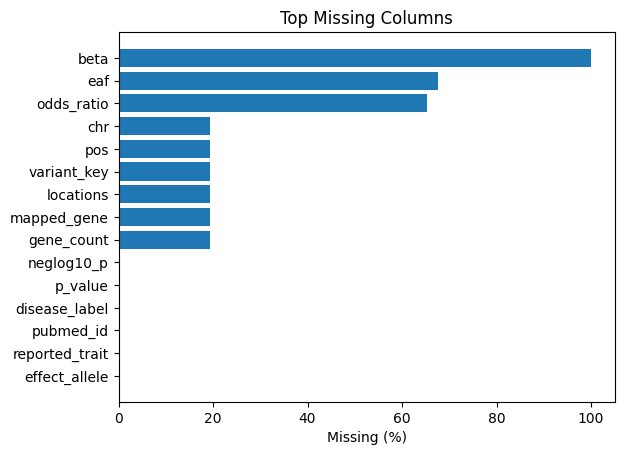

In [27]:
missing_pct = (df.isna().mean().sort_values(ascending=False) * 100)
display(missing_pct.to_frame("missing_%").head(20))

top_missing = missing_pct.head(15).sort_values()
plt.figure()
plt.barh(top_missing.index, top_missing.values)
plt.xlabel("Missing (%)")
plt.title("Top Missing Columns")
plt.show()

Dataset imbalanced: Alzheimer's >> Parkinson's. This matters for modeling

In [28]:
miss_by_disease = df.groupby("disease_label")[CORE].apply(lambda x: x.isna().mean()*100)
miss_by_disease

,disease_label,chr,pos,variant_key,p_value,neglog10_p,odds_ratio,eaf,mapped_gene,gene_count,reported_trait,study_accession
disease_label,,,,,,,,,,,,
Alzheimers,0.0,21.123077,21.123077,21.123077,0.046154,0.046154,65.784615,69.230769,21.046154,21.046154,0.0,0.0
Parkinsons,0.0,4.247104,4.247104,4.247104,0.000000,0.000000,61.518662,54.054054,4.247104,4.247104,0.0,0.0


This gives more information as to the percentage of data missing per column per disease.

### Descriptive Statistics

In [29]:
NUM = ["p_value", "neglog10_p", "odds_ratio", "eaf", "gene_count"]
NUM = [c for c in NUM if c in df.columns]

df.groupby("disease_label")[NUM].describe()

p_value                                                       \
                count          mean       std            min           25%   
disease_label                                                                
Alzheimers     6497.0  1.396029e-06  0.000003  9.881313e-324  2.000000e-11   
Parkinsons      777.0  6.573874e-07  0.000002  8.000000e-240  1.000000e-13   

                                                   neglog10_p             ...  \
                        50%           75%      max      count       mean  ...   
disease_label                                                             ...   
Alzheimers     2.000000e-08  1.000000e-06  0.00001     6497.0  13.655627  ...   
Parkinsons     1.000000e-09  3.000000e-07  0.00001      777.0  14.099824  ...   

                    eaf         gene_count                                     \
                    75%     max      count      mean       std  min  25%  50%   
disease_label                                                                   
Alzheimers     0.566299  0.9993     5132.0  1.426539  0.507074  1.0  1.0  1.0   
Parkinsons     0.665000  0.9997      744.0  1.306452  0.461330  1.0  1.0  1.0   

                         
               75%  max  
disease_label            
Alzheimers     2.0  6.0  
Parkinsons     2.0  2.0  

[2 rows x 40 columns]

As was noted before, there is an imbalance in the data favoring Alzheimer's.

Both diseases contain very significant associations overall with very low p-values. Parkinson's does however show a slightly higher significance.

Most records map to one gene but Alzheimer's includes more multi-gene mappings.


### Distribution Visuals

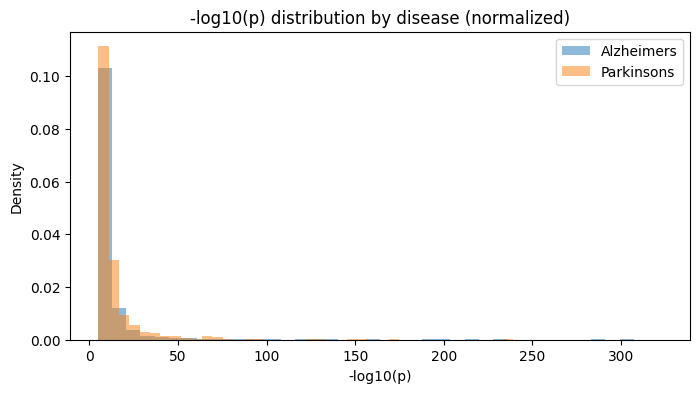

In [30]:
plt.figure(figsize=(8,4))
for label, g in df.groupby("disease_label"):
    plt.hist(g["neglog10_p"].dropna(), bins=40, alpha=0.5, label=label, density=True)
plt.title("-log10(p) distribution by disease (normalized)")
plt.xlabel("-log10(p)")
plt.ylabel("Density")
plt.legend()
plt.show()

After normalizing for sample size, Alzheimer's and Parkinson's show similar -log10(p) distributions with a strong right skew. Parkinson's appears modestly shifted toward higher -log10(p), indicating a slightly larger share of highly significant associations in this dataset.

### Odds Ratio by Disease

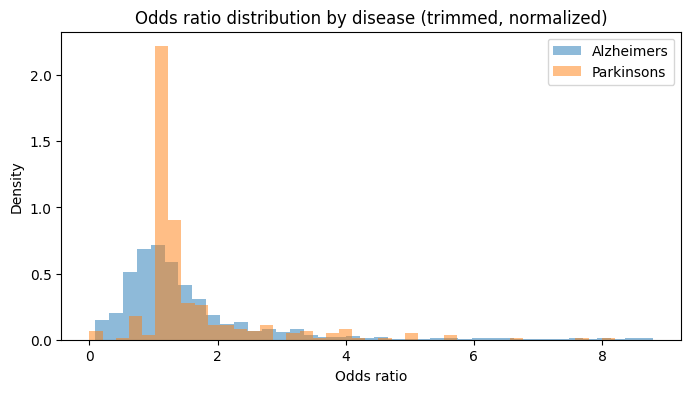

In [31]:
tmp = df.dropna(subset=["odds_ratio"]).copy()
tmp = tmp[(tmp["odds_ratio"] > 0) & (tmp["odds_ratio"] < tmp["odds_ratio"].quantile(0.99))]

plt.figure(figsize=(8,4))
for label, g in tmp.groupby("disease_label"):
    plt.hist(g["odds_ratio"], bins=40, alpha=0.5, label=label, density=True)
plt.title("Odds ratio distribution by disease (trimmed, normalized)")
plt.xlabel("Odds ratio")
plt.ylabel("Density")
plt.legend()
plt.show()

In this analysis, effect refers to the magnitude of association between a genetic variant and disease risk. This is measured by the odds ratio, which quantifies how much the presence of a variant changes the odds of developing the disease.

The normalized odds ratio distributions show that both diseases are dominated by modest effect sizes (OR about 1-1.5). Parkinson's associations are more tightly concentrated near small effects, while Alzheimer's exhibits greater dispersion and a heavier right tail, indicating a wider range of reported effect magnitudes.

### EAF by Disease

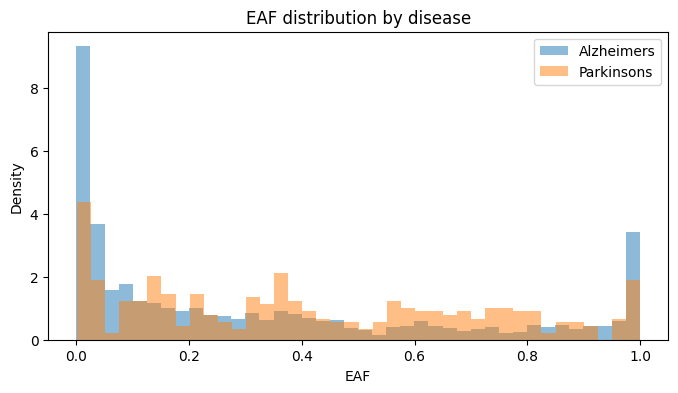

In [32]:
tmp = df.dropna(subset=["eaf"]).copy()
tmp = tmp[(tmp["eaf"] >= 0) & (tmp["eaf"] <= 1)]

plt.figure(figsize=(8,4))
for label, g in tmp.groupby("disease_label"):
    plt.hist(g["eaf"], bins=40, alpha=0.5, label=label, density=True)
plt.title("EAF distribution by disease")
plt.xlabel("EAF")
plt.ylabel("Density")
plt.legend()
plt.show()

EAF = Effect Allele Frequency

This measure tells you how common the risk allele is in a population.

After normalizing, we can see that both Alzheimer's and Parkinson's share a large spike around zero indicating a lot of reported associations involve rare/low frequency effect alleles.

Parkinson's has more mass from around 0.3 to 0.8 meaning its associations include a larger portion of common variants not just rare ones.

The spike for both diseases around 1 means these effect alleles are extremely common likely due to allele coding choices in the original data.

### Relationship/Correlation

In [33]:
df[["neglog10_p","odds_ratio","eaf","gene_count"]].corr(numeric_only=True)

,neglog10_p,odds_ratio,eaf,gene_count
neglog10_p,1.000000,0.054906,0.018400,-0.060717
odds_ratio,0.054906,1.000000,-0.184159,-0.013509
eaf,0.018400,-0.184159,1.000000,-0.045031
gene_count,-0.060717,-0.013509,-0.045031,1.000000


The correlation matrix indicates weak linear relationships among statistical significance, effect size, allele frequency, and gene count, with the strongest, though still modest, association being a slight negative correlation between allele frequency and odds ratio (r aprox. -0.18). This is a good sign as this tells us no variable is redundant.

### Counts by Chromosome Visualization

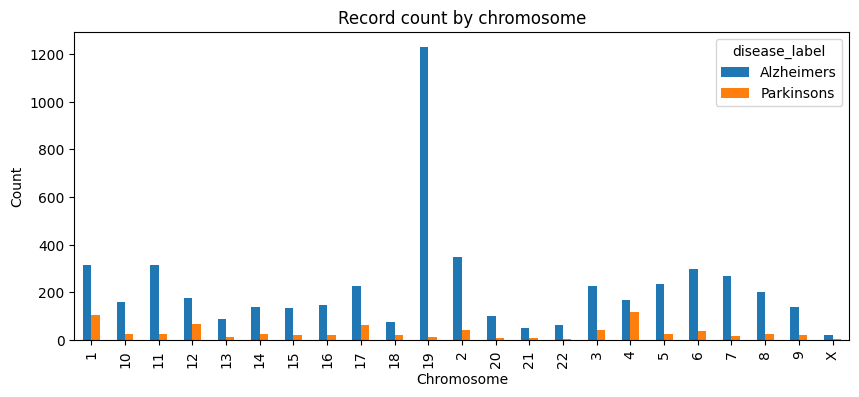

In [34]:
tmp = df.dropna(subset=["chr"]).copy()
chr_counts = tmp.groupby(["chr","disease_label"]).size().unstack(fill_value=0)

chr_counts.plot(kind="bar", figsize=(10,4))
plt.title("Record count by chromosome")
plt.xlabel("Chromosome")
plt.ylabel("Count")
plt.show()

This plot shows Alzheimer's associations are highly enriched on chromosome 19 relative to other chromosomes, whereas Parkinson's associations appear more evenly distributed across chromosomes.

Upon further research it appears chromosome 19 is known to have a strong association with alzheimers due to the apolipoprotein cluster on chromosome 19. It is likely several genes within this that are associated with late on set of the disease.

### Preliminary Results

In [35]:
top = df.dropna(subset=["neglog10_p"]).sort_values("neglog10_p", ascending=False)

top10_mappable = (
    top.dropna(subset=["variant_key","chr","pos"])
       .groupby("disease_label")
       .head(10)
)

top10_mappable[["disease_label","variant_key","chr","pos","p_value","neglog10_p","mapped_gene","study_accession"]]

,disease_label,variant_key,chr,pos,p_value,neglog10_p,mapped_gene,study_accession
1790,Alzheimers,19:44908684,19,44908684.0,9.881313e-324,323.005185,APOE,GCST90480731
1445,Alzheimers,19:44908684,19,44908684.0,9.999889e-321,320.000005,APOE,GCST90654655
942,Alzheimers,19:44913484,19,44913484.0,2.000000e-308,307.698970,APOC1,GCST90449058
3600,Alzheimers,19:44908684,19,44908684.0,3.000000e-305,304.522879,APOE,GCST90624094
1896,Alzheimers,19:44908684,19,44908684.0,7.000000e-305,304.154902,APOE,GCST90624093
611,Alzheimers,19:44908684,19,44908684.0,2.000000e-303,302.698970,APOE,GCST009019
2670,Alzheimers,19:44908684,19,44908684.0,1.000000e-300,300.000000,APOE,GCST90012877
234,Alzheimers,19:44908684,19,44908684.0,1.000000e-300,300.000000,APOE,GCST90044699
2669,Alzheimers,19:44862190,19,44862190.0,1.000000e-300,300.000000,NECTIN2,GCST90012877
2671,Alzheimers,19:44915229,19,44915229.0,1.000000e-300,300.000000,APOC1,GCST90012877


Gives top 10 most significant hits per disease given they don't have NaN in their mapping.

Alzheimer's top signals are dominated by chromosome 19 near APOE region genes.The mapped genes include APOE repeatedly, plus APOC1, and NECTIN2.

Parkinson's top signals cluster heavily on chromosome 4, plus a few other loci. The mapped gene is repeatedly SNCA.

In this dataset, the most significant Alzheimer's hits have substantially larger -log10(p) values than the most significant Parkinson's hits, though this may reflect differences in study size and design rather than biology.



# Download Cleaned Dataset

In [36]:
Alz_Pd_Clean = df.copy()

Alz_Pd_Clean.to_csv("Alz_Pd_Clean.csv", index=False)

from google.colab import files
files.download("Alz_Pd_Clean.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>